In [1]:
import pandas as pd
import numpy as np
import blinksear as ear
import blinksdistance as distance
import blinkscolors as colors
import json
import matplotlib.pyplot as plt
from pathlib import Path

from outofplane import isOutOfPlane

In [2]:
def generate_webgazer_dataframe(df):
    df_webgazer = df[~df["webgazer_data"].isna()]
    dfs = []
    for row in range(len(df_webgazer)):
        data_list = json.loads(df_webgazer["webgazer_data"].iloc[row])
        df_tmp = pd.DataFrame(data_list)
        df_tmp["trial"] = row + 1
        dfs.append(df_tmp)
    return pd.concat(dfs)

In [4]:
# This can load all data but is not storing df_webgazer in any place
files = Path("./data").glob("*.csv")
dfs = []
i = 0
for file in files:
    if "rotation" in str(file):
        print(file)
        df = pd.read_csv(file)
        df_tmp = generate_webgazer_dataframe(df)
        print(len(df_tmp))
        df_tmp["experiment"] = i
        df_tmp["file_name"] = str(file)
        i+=1
        dfs.append(df_tmp)

df_webgazer = pd.concat(dfs)
print(len(df_webgazer))

data/rotation-experiment-11.csv
1294
data/rotation-experiment-10.csv
1676
data/rotation-experiment-12.csv
2249
data/rotation-experiment-13.csv
1398
data/rotation-experiment-14.csv
1314
data/rotation-experiment-15.csv
1406
data/rotation-experiment-9.csv
2724
data/rotation-experiment-8.csv
3676
data/rotation-experiment-5.csv
2413
data/rotation-experiment-expose-points_1.csv
2530
data/rotation-experiment-6.csv
3450
data/rotation-experiment-7.csv
2270
26400


In [6]:
df_webgazer["isRotated"] = df_webgazer["importantKeypoints"].map(
    lambda x: isOutOfPlane(x)
)

# df_webgazer['isBlinkByEar'] = df_webgazer['importantKeypoints'].map(lambda x: isBlinkByEar(x['rightEyeTopArc'], x['rightEyeBottomArc'], x['leftEyeTopArc'], x['leftEyeBottomArc']))

df_webgazer

,x,y,t,importantKeypoints,dz,trial,experiment,file_name,leftEye,rightEye,isBlinkByEar,isRotated
0,0,0,4,"{'noseX': 322.88, 'noseY': 260.29, 'topY': 157...",52.85,1,0,data/rotation-experiment-11.csv,NaN,NaN,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
1,0,0,38,"{'noseX': 322.92, 'noseY': 259.99, 'topY': 156...",53.07,1,0,data/rotation-experiment-11.csv,NaN,NaN,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
2,0,0,73,"{'noseX': 321.95, 'noseY': 259.69, 'topY': 157...",52.28,1,0,data/rotation-experiment-11.csv,NaN,NaN,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
3,0,0,106,"{'noseX': 322.28, 'noseY': 259.91, 'topY': 156...",51.81,1,0,data/rotation-experiment-11.csv,NaN,NaN,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
4,0,0,142,"{'noseX': 322.06, 'noseY': 259.65, 'topY': 156...",52.24,1,0,data/rotation-experiment-11.csv,NaN,NaN,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
...,...,...,...,...,...,...,...,...,...,...,...,...
118,0,0,4016,"{'noseX': 333.76, 'noseY': 337.38, 'topY': 196...",39.75,9,11,data/rotation-experiment-7.csv,NaN,NaN,"[False, False, False, False, True, True, True,...","[False, False, False, False, True, True, True,..."
119,0,0,4049,"{'noseX': 333.74, 'noseY': 336.54, 'topY': 195...",39.38,9,11,data/rotation-experiment-7.csv,NaN,NaN,"[False, False, False, False, True, True, True,...","[False, False, False, False, True, True, True,..."
120,0,0,4083,"{'noseX': 333.7, 'noseY': 335.87, 'topY': 195....",38.53,9,11,data/rotation-experiment-7.csv,NaN,NaN,"[False, False, False, False, True, True, True,...","[False, False, False, False, True, True, True,..."
121,0,0,4117,"{'noseX': 333.7, 'noseY': 335.25, 'topY': 195....",38.05,9,11,data/rotation-experiment-7.csv,NaN,NaN,"[False, False, False, False, True, True, True,...","[False, False, False, False, True, True, True,..."


In [7]:
df_webgazer["Rotation_threshold"] = df_webgazer["isRotated"].apply(lambda x: int(x[0]==True))
df_webgazer["Rotation_threshold1"] = df_webgazer["isRotated"].apply(lambda x: int(x[1]==True)+1)
df_webgazer["Rotation_threshold2"] = df_webgazer["isRotated"].apply(lambda x: int(x[2]==True)+2)
df_webgazer["Rotation_threshold3"] = df_webgazer["isRotated"].apply(lambda x: int(x[3]==True)+3)
df_webgazer["Rotation_threshold4"] = df_webgazer["isRotated"].apply(lambda x: int(x[4]==True)+4)
df_webgazer["Rotation_threshold5"] = df_webgazer["isRotated"].apply(lambda x: int(x[5]==True)+5)
df_webgazer["Rotation_threshold6"] = df_webgazer["isRotated"].apply(lambda x: int(x[6]==True)+6)
df_webgazer["Rotation_threshold7"] = df_webgazer["isRotated"].apply(lambda x: int(x[7]==True)+7)

In [8]:
df_webgazer.head()

,x,y,t,importantKeypoints,dz,trial,experiment,file_name,leftEye,rightEye,isBlinkByEar,isRotated,Rotation_threshold,Rotation_threshold1,Rotation_threshold2,Rotation_threshold3,Rotation_threshold4,Rotation_threshold5,Rotation_threshold6,Rotation_threshold7
0,0,0,4,"{'noseX': 322.88, 'noseY': 260.29, 'topY': 157...",52.85,1,0,data/rotation-experiment-11.csv,NaN,NaN,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,1,2,3,4,5,6,8
1,0,0,38,"{'noseX': 322.92, 'noseY': 259.99, 'topY': 156...",53.07,1,0,data/rotation-experiment-11.csv,NaN,NaN,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,1,2,3,4,5,6,8
2,0,0,73,"{'noseX': 321.95, 'noseY': 259.69, 'topY': 157...",52.28,1,0,data/rotation-experiment-11.csv,NaN,NaN,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,1,2,3,4,5,6,8
3,0,0,106,"{'noseX': 322.28, 'noseY': 259.91, 'topY': 156...",51.81,1,0,data/rotation-experiment-11.csv,NaN,NaN,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,1,2,3,4,5,6,8
4,0,0,142,"{'noseX': 322.06, 'noseY': 259.65, 'topY': 156...",52.24,1,0,data/rotation-experiment-11.csv,NaN,NaN,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,1,2,3,4,5,6,7


/var/folders/bc/dx7gzw5x0d9_snwy574lpzc40000gn/T/ipykernel_15756/1673114883.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


<Figure size 1400x800 with 0 Axes>

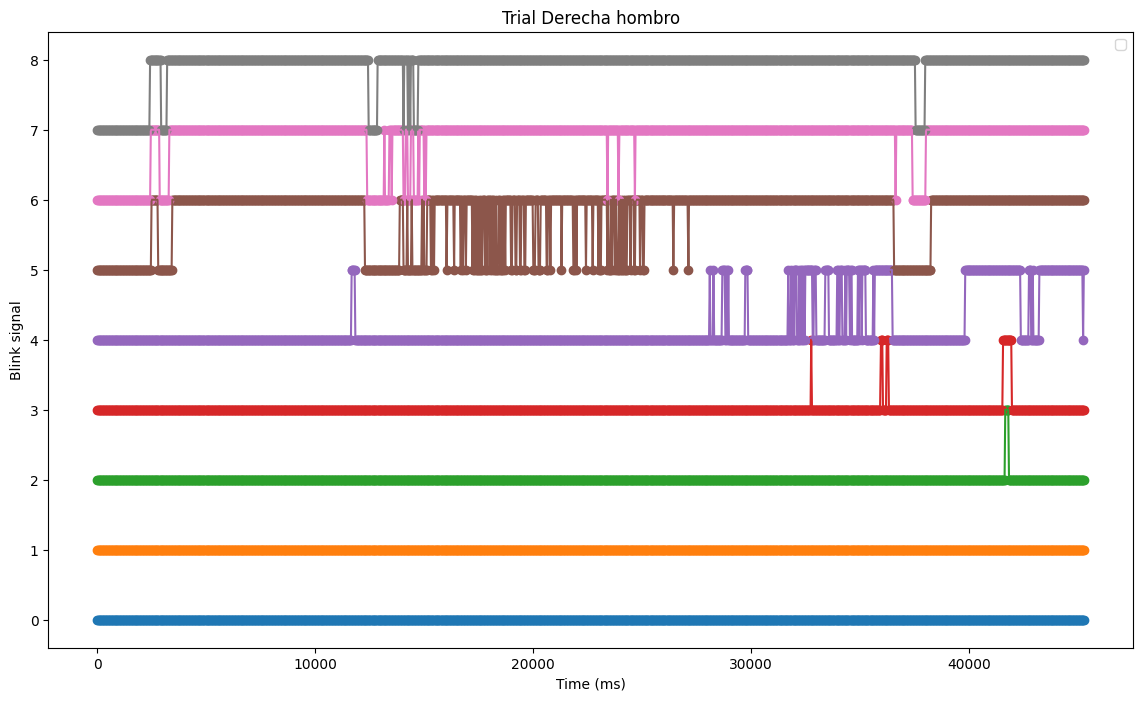

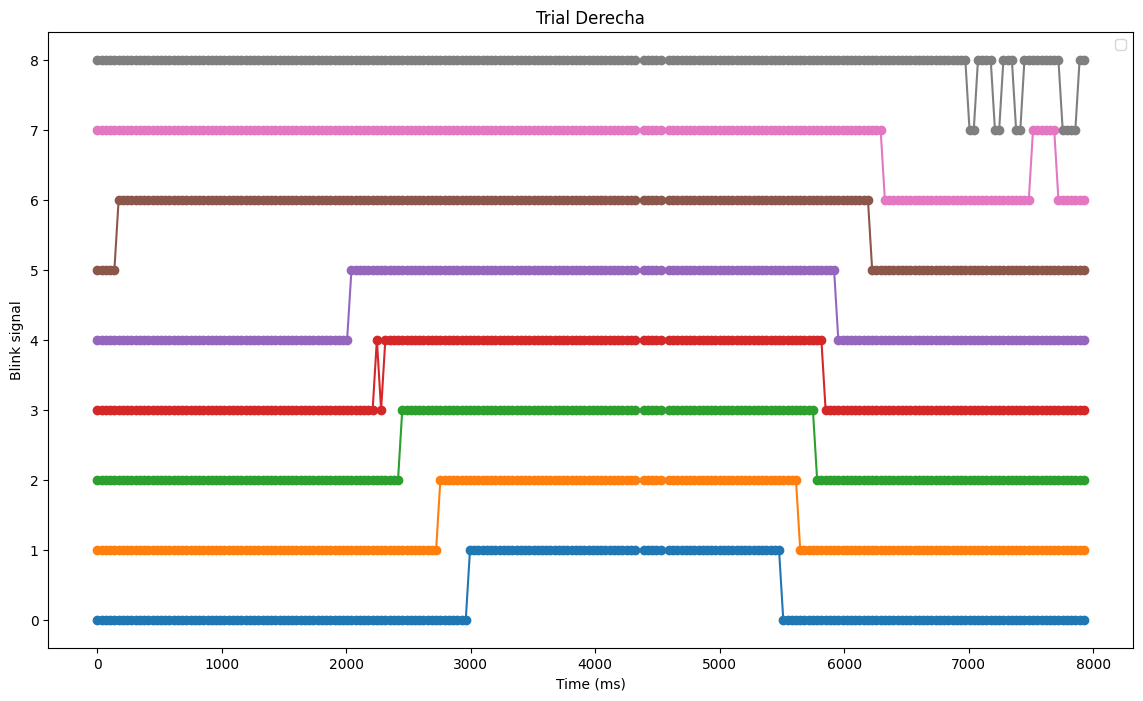

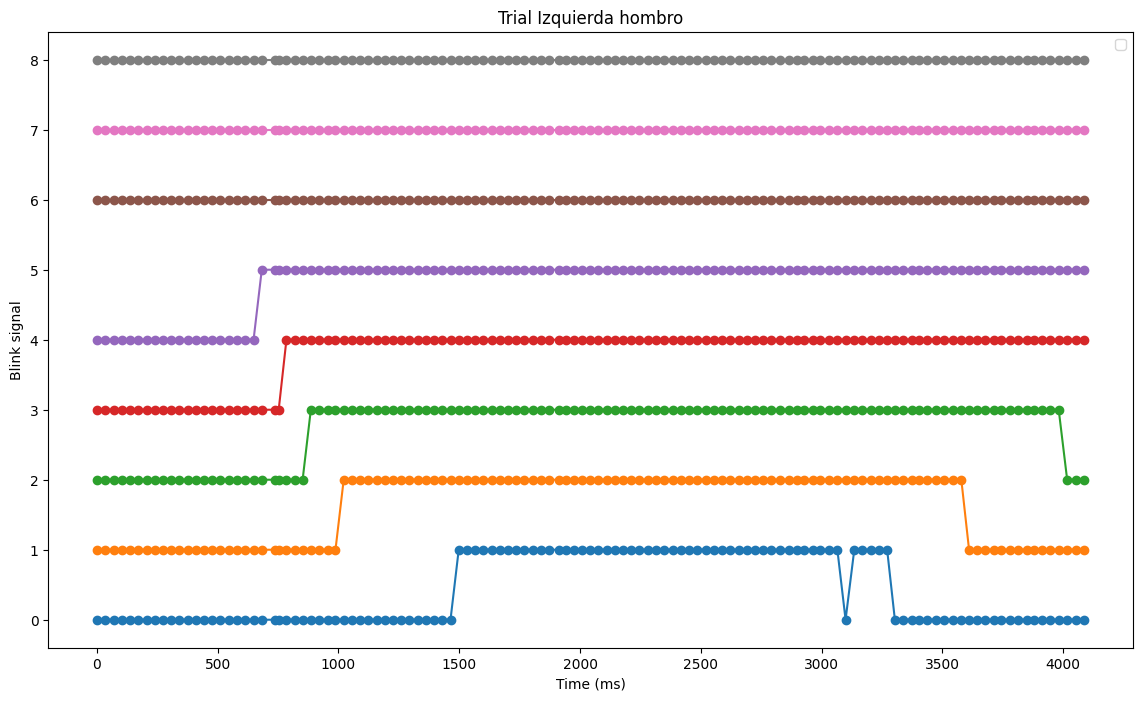

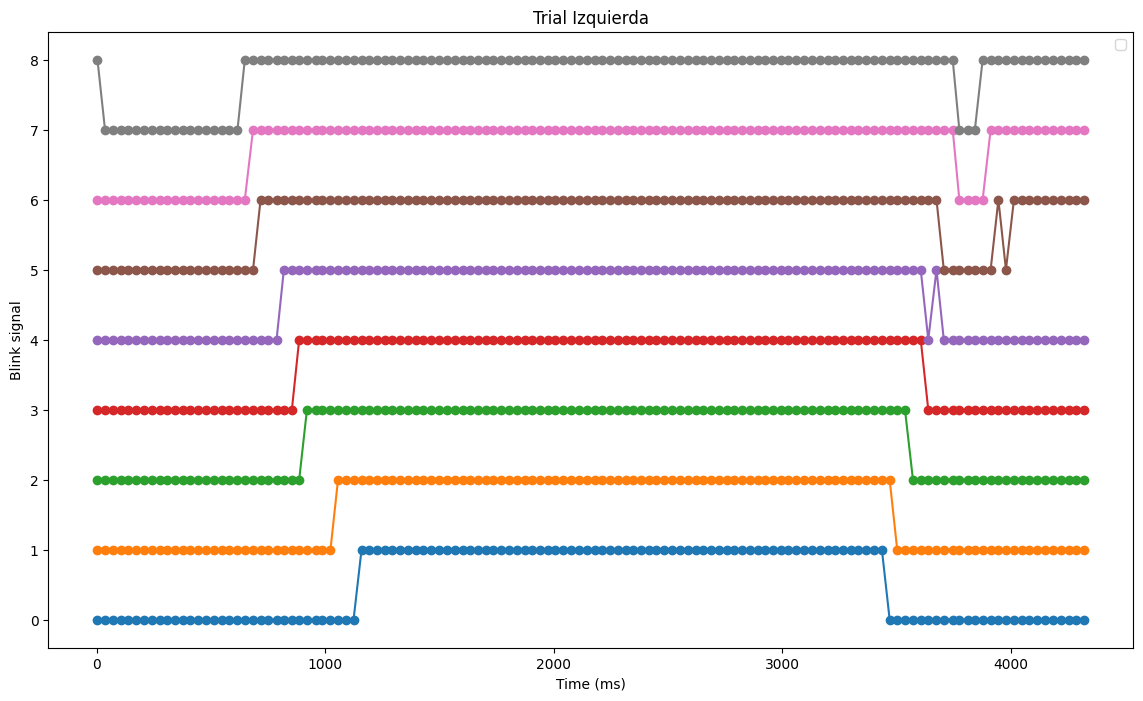

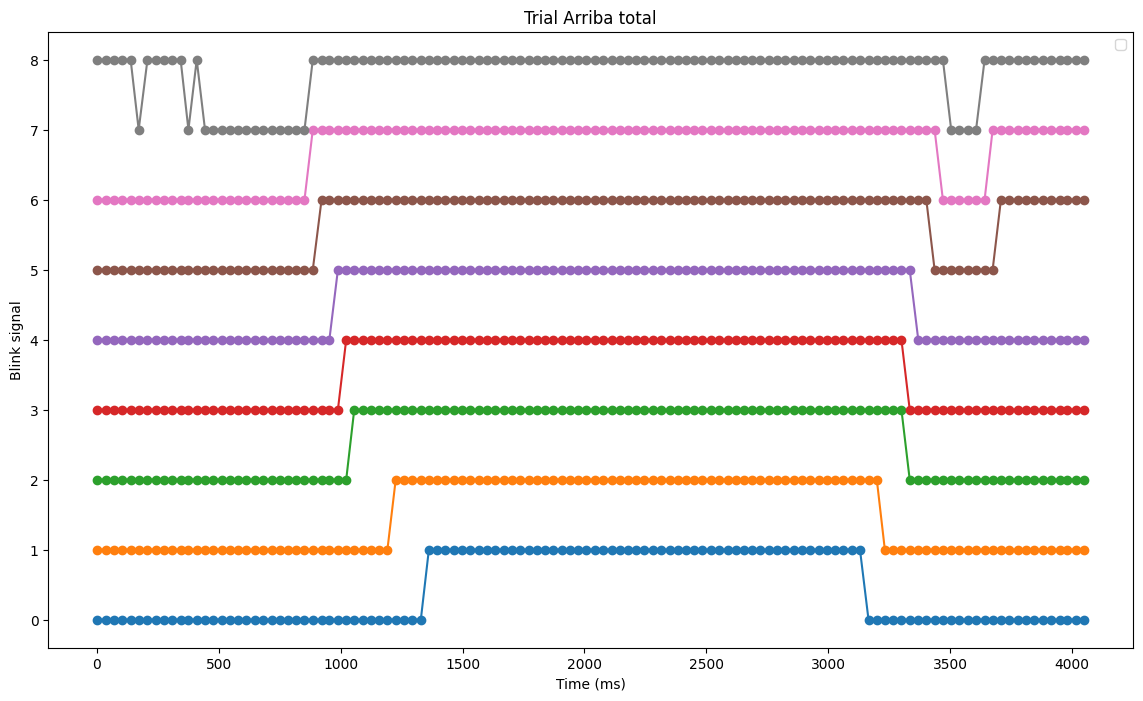

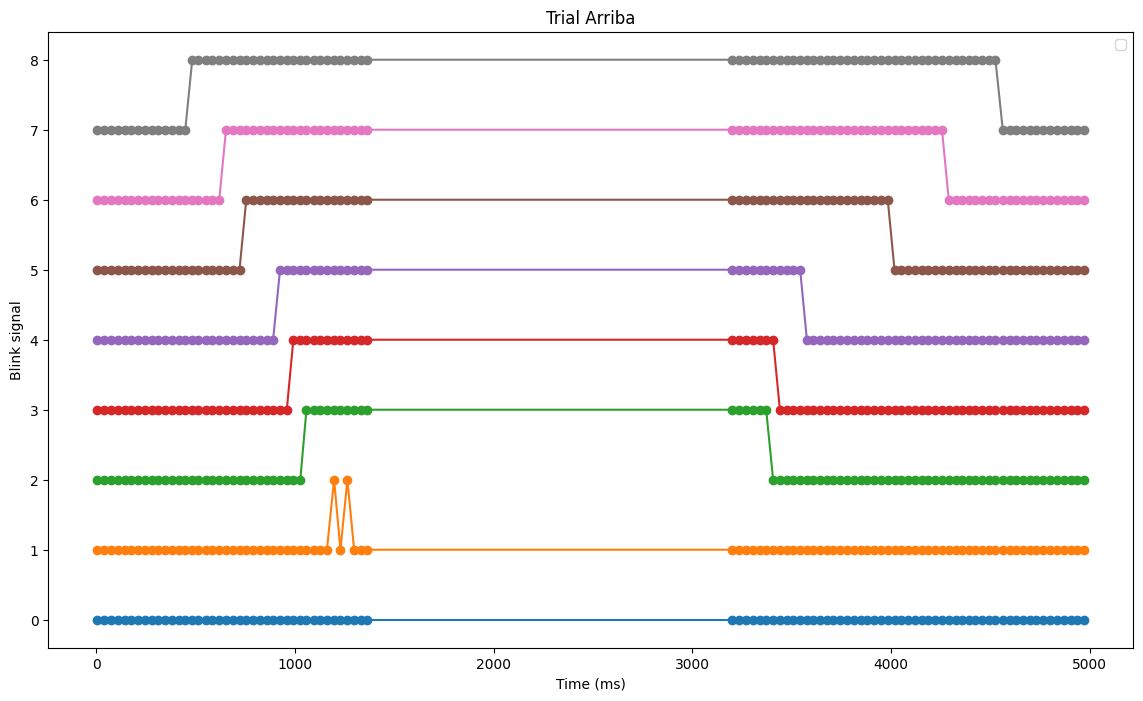

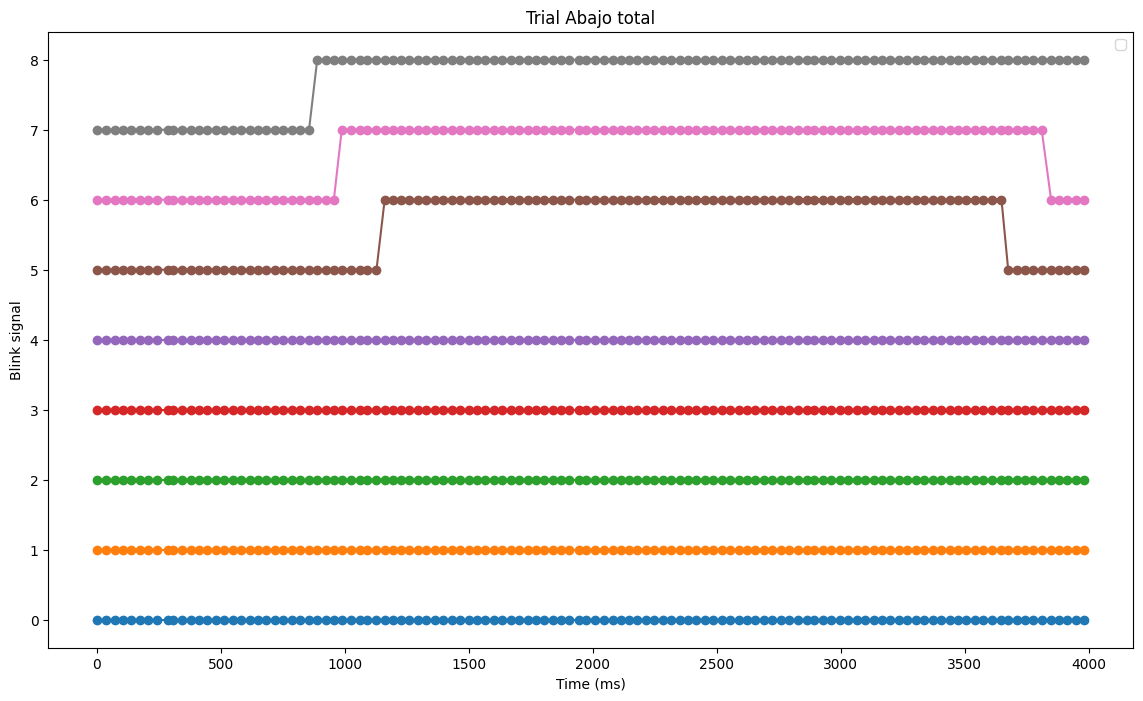

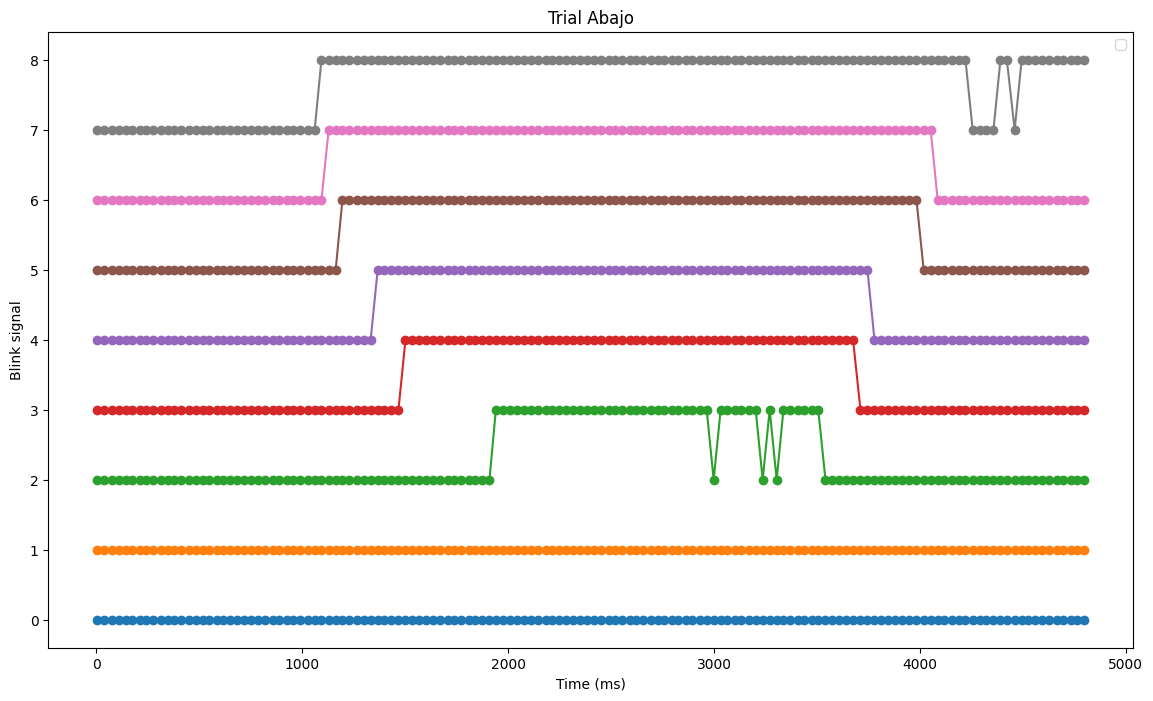

In [22]:
titles = ["Trial Derecha hombro",
          "Trial Derecha",
          "Trial Izquierda hombro",
          "Trial Izquierda",
          "Trial Arriba total",
          "Trial Arriba",
          "Trial Abajo total",
          "Trial Abajo"]

# Initialize the plot
plt.figure(figsize=(14, 8))

df_to_plot = df_webgazer[df_webgazer["experiment"]==8]

#df_webgazer[df_webgazer["trial"]==1].plot(x="t", y="Rotation_threshold", legend=False)
#df_webgazer[df_webgazer["trial"]==1].plot(x="t", y="Rotation_threshold1", legend=False)
for x in range(8):
  plt.figure(figsize=(14, 8))
  plt.plot(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold)
  plt.plot(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold1)
  plt.plot(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold2)
  plt.plot(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold3)
  plt.plot(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold4)
  plt.plot(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold5)
  plt.plot(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold6)
  plt.plot(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold7)
  plt.scatter(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold)
  plt.scatter(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold1)
  plt.scatter(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold2)
  plt.scatter(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold3)
  plt.scatter(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold4)
  plt.scatter(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold5)
  plt.scatter(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold6)
  plt.scatter(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold7)
  plt.title(titles[x])
  plt.xlabel("Time (ms)")
  plt.ylabel("Blink signal")
  plt.legend(loc="upper right")
  plt.show()




# Plot the blink data using different colors for each type

# Add labels and legend
#plt.title("Blink Scatter Plot")
#plt.xlabel("Time (ms)")
#plt.ylabel("Trial")
#plt.legend(loc="upper right")

# Show plot
#plt.show()


In [10]:
df_webgazer['Rotation_threshold3'][df_webgazer['Rotation_threshold3'].diff()>0].shape

(186,)

In [11]:
df_webgazer["Rotation_threshold0_diff"] = (df_webgazer['Rotation_threshold'].shift(1)+1 == df_webgazer['Rotation_threshold'])
df_webgazer["Rotation_threshold1_diff"] = (df_webgazer['Rotation_threshold1'].shift(1)+1 == df_webgazer['Rotation_threshold1'])
df_webgazer["Rotation_threshold2_diff"] = (df_webgazer['Rotation_threshold2'].shift(1)+1 == df_webgazer['Rotation_threshold2'])
df_webgazer["Rotation_threshold3_diff"] = (df_webgazer['Rotation_threshold3'].shift(1)+1 == df_webgazer['Rotation_threshold3'])
df_webgazer["Rotation_threshold4_diff"] = (df_webgazer['Rotation_threshold4'].shift(1)+1 == df_webgazer['Rotation_threshold4'])
df_webgazer["Rotation_threshold5_diff"] = (df_webgazer['Rotation_threshold5'].shift(1)+1 == df_webgazer['Rotation_threshold5'])
df_webgazer["Rotation_threshold6_diff"] = (df_webgazer['Rotation_threshold6'].shift(1)+1 == df_webgazer['Rotation_threshold6'])
df_webgazer["Rotation_threshold7_diff"] = (df_webgazer['Rotation_threshold7'].shift(1)+1 == df_webgazer['Rotation_threshold7'])

results = []
for x in range(0,8):
    tmp_result = df_webgazer.groupby('trial')['Rotation_threshold' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

result = pd.concat(results, axis=1, join='inner')
result

,trial,Rotation_threshold0_diff,trial,Rotation_threshold1_diff,trial,Rotation_threshold2_diff,trial,Rotation_threshold3_diff,trial,Rotation_threshold4_diff,trial,Rotation_threshold5_diff,trial,Rotation_threshold6_diff,trial,Rotation_threshold7_diff
0,1,15,1,24,1,37,1,79,1,160,1,269,1,146,1,65
1,2,14,2,13,2,13,2,14,2,14,2,29,2,26,2,27
2,3,16,3,10,3,10,3,10,3,10,3,24,3,23,3,15
3,4,15,4,15,4,17,4,16,4,18,4,20,4,30,4,22
4,5,17,5,12,5,13,5,11,5,11,5,11,5,31,5,28
5,6,1,6,15,6,34,6,26,6,21,6,21,6,24,6,36
6,7,0,7,0,7,0,7,2,7,4,7,15,7,61,7,36
7,8,0,8,10,8,20,8,14,8,16,8,15,8,14,8,17
8,9,0,9,0,9,14,9,14,9,11,9,16,9,10,9,16


In [12]:
results = []
for x in range(0,8):
    tmp_result = df_webgazer[df_webgazer['trial']==3].groupby('file_name')['Rotation_threshold' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

result = pd.concat(results, axis=1, join='inner')
result

,file_name,Rotation_threshold0_diff,file_name,Rotation_threshold1_diff,file_name,Rotation_threshold2_diff,file_name,Rotation_threshold3_diff,file_name,Rotation_threshold4_diff,file_name,Rotation_threshold5_diff,file_name,Rotation_threshold6_diff,file_name,Rotation_threshold7_diff
0,data/rotation-experiment-10.csv,1,data/rotation-experiment-10.csv,1,data/rotation-experiment-10.csv,1,data/rotation-experiment-10.csv,1,data/rotation-experiment-10.csv,1,data/rotation-experiment-10.csv,1,data/rotation-experiment-10.csv,4,data/rotation-experiment-10.csv,2
1,data/rotation-experiment-11.csv,1,data/rotation-experiment-11.csv,1,data/rotation-experiment-11.csv,1,data/rotation-experiment-11.csv,1,data/rotation-experiment-11.csv,1,data/rotation-experiment-11.csv,1,data/rotation-experiment-11.csv,3,data/rotation-experiment-11.csv,5
2,data/rotation-experiment-12.csv,1,data/rotation-experiment-12.csv,1,data/rotation-experiment-12.csv,1,data/rotation-experiment-12.csv,1,data/rotation-experiment-12.csv,1,data/rotation-experiment-12.csv,7,data/rotation-experiment-12.csv,5,data/rotation-experiment-12.csv,1
3,data/rotation-experiment-13.csv,1,data/rotation-experiment-13.csv,1,data/rotation-experiment-13.csv,1,data/rotation-experiment-13.csv,1,data/rotation-experiment-13.csv,1,data/rotation-experiment-13.csv,2,data/rotation-experiment-13.csv,0,data/rotation-experiment-13.csv,0
4,data/rotation-experiment-14.csv,0,data/rotation-experiment-14.csv,0,data/rotation-experiment-14.csv,0,data/rotation-experiment-14.csv,0,data/rotation-experiment-14.csv,0,data/rotation-experiment-14.csv,0,data/rotation-experiment-14.csv,8,data/rotation-experiment-14.csv,7
5,data/rotation-experiment-15.csv,0,data/rotation-experiment-15.csv,0,data/rotation-experiment-15.csv,0,data/rotation-experiment-15.csv,0,data/rotation-experiment-15.csv,0,data/rotation-experiment-15.csv,0,data/rotation-experiment-15.csv,0,data/rotation-experiment-15.csv,0
6,data/rotation-experiment-5.csv,2,data/rotation-experiment-5.csv,1,data/rotation-experiment-5.csv,1,data/rotation-experiment-5.csv,1,data/rotation-experiment-5.csv,1,data/rotation-experiment-5.csv,1,data/rotation-experiment-5.csv,1,data/rotation-experiment-5.csv,0
7,data/rotation-experiment-6.csv,1,data/rotation-experiment-6.csv,1,data/rotation-experiment-6.csv,1,data/rotation-experiment-6.csv,1,data/rotation-experiment-6.csv,1,data/rotation-experiment-6.csv,0,data/rotation-experiment-6.csv,0,data/rotation-experiment-6.csv,0
8,data/rotation-experiment-7.csv,1,data/rotation-experiment-7.csv,1,data/rotation-experiment-7.csv,1,data/rotation-experiment-7.csv,1,data/rotation-experiment-7.csv,1,data/rotation-experiment-7.csv,0,data/rotation-experiment-7.csv,0,data/rotation-experiment-7.csv,0
9,data/rotation-experiment-8.csv,1,data/rotation-experiment-8.csv,1,data/rotation-experiment-8.csv,1,data/rotation-experiment-8.csv,1,data/rotation-experiment-8.csv,1,data/rotation-experiment-8.csv,7,data/rotation-experiment-8.csv,0,data/rotation-experiment-8.csv,0


In [13]:
df_webgazer.groupby('trial')['Rotation_threshold6_diff'].sum().reset_index()


,trial,Rotation_threshold6_diff
0,1,146
1,2,26
2,3,23
3,4,30
4,5,31
5,6,24
6,7,61
7,8,14
8,9,10
